# Parameter recovery

This notebook runs parameter recovery tests for the model used in all the main analysis. This is the model-based learner model that assumes participants are learning the tasks' transition structure and using this to make model-based decisions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from behavioural_modelling.learning.beta_models import beta_mean_var

from transition_uncertainty.data import load_and_process_data
from transition_uncertainty.modelling_utils import (
    generate_simulation_parameters,
    get_simulation_params,
    load_task_spec,
)
from transition_uncertainty.optimisation import optim_func, optimize_with_optax
from transition_uncertainty.style import set_style
from transition_uncertainty.utils import check_directories

# Make sure we're in the right directory
check_directories()

set_style("style.mplstyle")

/scratch_tmp/users/k1327409/miniconda3/envs/transition_uncertainty/lib/python3.11/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


Font Heebo already available in Matplotlib.
Matplotlib style set to: style.mplstyle with font Heebo


## Load in task spec

First, we load in the details of the task (e.g., the outcomes on each trial).

In [3]:
# Load task specification
(
    second_stage_states,
    second_stage_state_probs,
    rewards,
    reward_probs,
    available_side,
) = load_task_spec("data/task_spec")

# Determine the number of trials from the shape of the loaded data
N_TRIALS = second_stage_states.shape[1]

## Simulate data

We then use this information to simulate data from the model with a range of parameter values.

In [4]:
n_subs = 1
task_spec_path = "data/task_spec"

# Generate simulation parameters and unpack the returned values.
(
    second_stage_states_all,
    rewards_all,
    reward_probs_all,
    available_side_all,
    available_side,
    starting_value_estimate,
    starting_transition_prob_estimate,
    params_dict,
    true_params_array,
) = generate_simulation_parameters(n_subs, task_spec_path)

# Parameters that are common across all model types
common_params = [
    starting_value_estimate,
    starting_transition_prob_estimate,
    second_stage_states_all,
    reward_probs_all,
    rewards_all,
    available_side_all,
]

# Get simulation parameters
simulate_params_beta = get_simulation_params(
    "mb_only", params_dict, np.ones_like(params_dict["W"]), common_params
)

## Get the best option on every trial

This is the option that leads to a second stage that will provide a reward.

In [5]:
# Get the best option (i.e., the option that leads to a reward second stage state)
best_option = np.stack(
    [
        (
            second_stage_states_all[0, 0, available_side[0, :] == -1, :]
            * rewards_all[0, 0, available_side[0, :] == -1, :]
        ).sum(axis=1),
        (
            (1 - second_stage_states_all[0, 0, available_side[0, :] == -1, :])
            * rewards_all[0, 0, available_side[0, :] == -1, :]
        ).sum(axis=1),
    ],
    axis=1,
)

## Optimise parameter values

We use [Optax](https://github.com/google-deepmind/optax) to find the parameter values that maximise the probability of selecting the best option on each trial.

In [6]:
# Set initial parameters and bounds
init_params = np.array([0.5, 0.5, 0.1])  # Initial tau, decay, temperature
bounds = [
    (0.01, 1.0),  # Bounds for tau_prob
    (0.01, 1.0),  # Bounds for decay_prob
    (0.05, 0.2),  # Bounds for temperature
]

# Optimize the model
optimized_params = optimize_with_optax(
    best_option, available_side, simulate_params_beta, init_params, bounds
)
print("Optimized Parameters:", optimized_params)

Step 0, Loss: -106.407547, Best Loss: -106.407547
Step 100, Loss: -112.879562, Best Loss: -112.879562
Early stopping at step 153 with best loss: -112.879616
Optimized Parameters: [1.        0.7643107 0.05     ]


## Extract uncertainty from the model

We can derive the full Beta distribution over transition probabilities from the model and use this to calculate reducible uncertainty on each trial. We can then average this to get the mean uncertainty over trials.

In [7]:
_, choice_p, beta_dists = optim_func(
    optimized_params, best_option, simulate_params_beta, available_side
)
choice_p = choice_p[:, 0]
uncertainty = beta_mean_var(beta_dists.squeeze())[1]
uncertainty = uncertainty[available_side[0, :] == -1]

# Get mean uncertainty
optimal_mean_uncertainty = uncertainty.mean()

print(f"Optimal mean uncertainty: {optimal_mean_uncertainty:.3f}")

Optimal mean uncertainty: 0.044


We can plot the probability of choosing the best option on each trial, and see that the model (as we'd expect) does well here. We can also show how uncertainty changes over the course of the task.

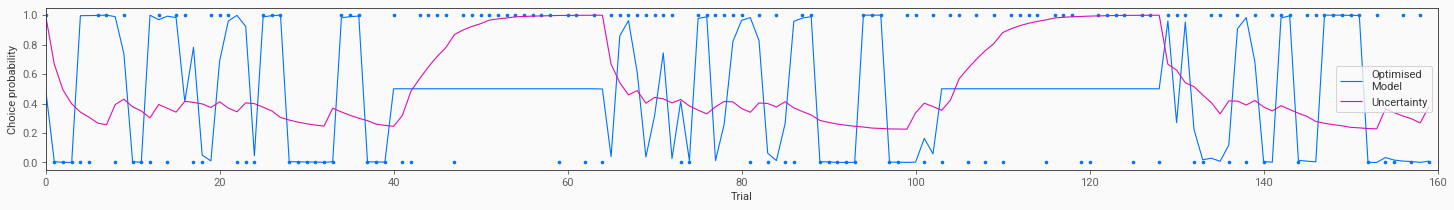

In [8]:
plt.figure(figsize=(20, 2.5))
plt.plot(choice_p, label="Optimised\nModel")
plt.plot(uncertainty / uncertainty.max(), label="Uncertainty")
plt.scatter(range(160), best_option[:, 0], s=5)
plt.xlabel("Trial")
plt.ylabel("Choice probability")
plt.xlim(0, 160)

plt.legend()

## Compare against the real data

We can then take a look at the uncertainty values from real participants' behaviour.

In [9]:
qdata_discovery = load_and_process_data(
    "discovery", scale=False, transform=False
)
qdata_replication = load_and_process_data(
    "replication", scale=False, transform=False
)

# combine
qdata = pd.concat([qdata_discovery, qdata_replication], ignore_index=True)

# Get mean uncertainty
mean_uncertainty = qdata["transition_var"].mean()

print("Mean uncertainty:", mean_uncertainty)

/scratch_tmp/users/k1327409/transition-learning-revision/transition_uncertainty/analysis_utils.py:104: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'pink' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  confidence_df.loc[confidence_df["pinkBet"] != 0, "bet_colour"] = "pink"


Initial number of subjects: 600
Number of included subjects after excluding gender != 0 or 1: 592
Number of included subjects after excluding age < 18 or >= 100: 592
Number of included subjects after excluding attention check failures: 551
Mean (SD) age = 40.75 (12.32)
n male = 275; n female = 276
Number scoring above cutoff for GAD: 116 (21.05%)
Number scoring above cutoff for MDD: 128 (23.23%)
Number of subjects after filtering and processing: 551
Initial number of subjects: 1400
Number of included subjects after excluding gender != 0 or 1: 1391
Number of included subjects after excluding age < 18 or >= 100: 1391
Number of included subjects after excluding attention check failures: 1322
Mean (SD) age = 41.15 (12.69)
n male = 655; n female = 667
Number scoring above cutoff for GAD: 243 (18.38%)
Number scoring above cutoff for MDD: 312 (23.6%)
Number of subjects after filtering and processing: 1322
Mean uncertainty: 0.07519421989408569


/scratch_tmp/users/k1327409/transition-learning-revision/transition_uncertainty/analysis_utils.py:104: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'pink' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  confidence_df.loc[confidence_df["pinkBet"] != 0, "bet_colour"] = "pink"


In [10]:
# Print proportion of participants with uncertainty higher than optimal
print(
    f"Proportion of participants with uncertainty higher than optimal: {np.mean(qdata['transition_var'] > optimal_mean_uncertainty):.3f}"
)

Proportion of participants with uncertainty higher than optimal: 0.967


And plot the distribution of uncertainty values, with the optimal value from the model as a reference.

Text(0, 0.5, 'Frequency')

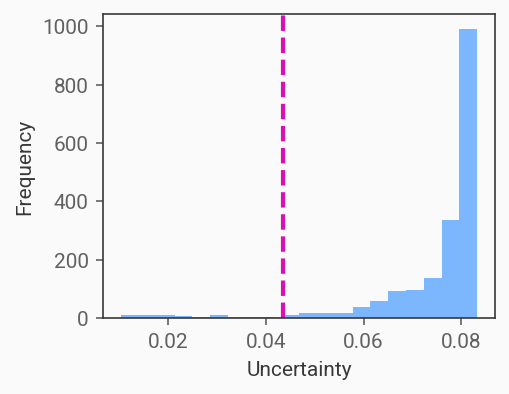

In [11]:
# set dpi higher
matplotlib.rcParams["figure.dpi"] = 150

# Get default colour cycle
colours = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]

f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
ax.hist(qdata["transition_var"], bins=20, alpha=0.5)
ax.axvline(
    optimal_mean_uncertainty, color=colours[1], linestyle="dashed", linewidth=2
)

ax.set_xlabel("Uncertainty")
ax.set_ylabel("Frequency")